# Quadratic Unconstrained Binary Optimization

Quadratic Unconstrained Binary Optimization (QUBO) refers to a broad class of optimization problems defined over binary variables with a quadratic objective function. QUBO formulations are closely connected to Ising models in physics, where the objective corresponds to minimizing an energy function. Many challenging combinatorial optimization problems, including graph problems such as Max-Cut and graph partitioning, scheduling problems such as nurse scheduling, routing and logistics problems such as the Traveling Salesperson Problem, and various matching problems, can be expressed in the QUBO framework. The close connection between QUBO problems and Ising models have paved the path for exploring a specific type of quantum hardware, quantum annealing, for solving such problems.

In this tutorial, we begin with the QUBO formulation and discuss how to transform constrained problems into QUBOs by introducing penalty terms. We then explore their fundamental connection to Ising models and explain how adiabatic quantum computers and quantum annealers leverage these models to find optimal solutions. Next, we examine the hierarchy of optimization problems to see where QUBO fits within the broader landscape of complexity. This is followed by a practical toy problem designed to demonstrate QUBO encoding and the simulation of quantum annealing using publicly available software packages. Moving toward real-world implementation, we address the challenges of mapping QUBO problems onto quantum hardware, focusing on minor embedding. Finally, we compare classical and quantum heuristic methods for solving these optimization problems before wrapping up with a concluding summary. 

### Table of Contents

1. QUBO Formulation
2. Transforming Constrained Problems into Unconstrained Form
3. Logical Connectives and Boolean Constraints
4. QUBO Representability
5. Connection with Ising Models
6. Adiabatic Quantum Computers and Quantum Annealers
7. Problems Expressible as QUBO
8. Optimization Problem Classes
9. Example 
10. Minor Embedding: Mapping Logic to Hardware
11. Performance Comparison: Quantum Annealing vs. Classical Approaches
12. Conclusion

### Appendices

13. Appendix 1: Biography
14. Appendix 2: References and Suggested Readings

---
### QUBO Formulation

Let $\boldsymbol{x} = (x_1, \ldots, x_n)$ be a vector of binary variables with each $x_i \in \{0,1\}$. 
Let $Q \in \mathbb{R}^{n \times n}$ be a real matrix encoding the coefficients of a quadratic objective function. 
Without loss of generality, the quadratic form may be represented using a symmetric matrix $Q$; alternatively, one may use an upper-triangular representation. The diagonal entries $Q_{ii}$ correspond to linear terms, while the off-diagonal entries $Q_{ij}$ for $i < j$ represent pairwise interaction weights between the variables $x_i$ and $x_j$.

The corresponding QUBO problem is to find a binary vector $\boldsymbol{x} \in \{0,1\}^n$ that minimizes the quadratic objective
$ \min\limits_{\boldsymbol{x} \in \{0,1\}^n} \boldsymbol{x}^\top Q \boldsymbol{x}. $
Equivalently, using the upper-triangular convention, this can be written as
$ \min\limits_{\boldsymbol{x} \in \{0,1\}^n} \left( \sum\limits_i Q_{ii} x_i + \sum\limits_{i<j} Q_{ij} x_i x_j \right). $

Hence, the QUBO problem can be defined as minimizing the function 
$f_Q : \mathbb{B}^n \rightarrow \mathbb{R}$, where $\mathbb{B}^n$ denotes the set of binary vectors of length $n$, and
$ f_Q(\boldsymbol{x}) = \sum\limits_i Q_{ii} x_i + \sum\limits_{i < j} Q_{ij} x_i x_j. $

The QUBO problem aims to find a binary vector $\boldsymbol{x}^\ast$ that minimizes $f_Q$. 
That is, $\forall \boldsymbol{x} \in \mathbb{B}^n: f_Q(\boldsymbol{x}^\ast) \leq f_Q(\boldsymbol{x})$.

In general, $\boldsymbol{x}^\ast$ may not be unique. Moreover, the number of possible binary vectors grows exponentially with $n$, since $|\mathbb{B}^n| = 2^n$.

To see the equivalence 
$$
\boldsymbol{x}^\top Q \boldsymbol{x}
= \sum_{i} Q_{ii} x_i + \sum_{i<j} Q_{ij} x_i x_j,
$$
we proceed step by step.

First, the identity
$$
\boldsymbol{x}^\top Q \boldsymbol{x}
= \sum_{i=1}^{n} \sum_{j=1}^{n} Q_{ij} x_i x_j
$$
follows directly from linear algebra: multiplying a row vector, a matrix, and a column vector expands into a double sum over all matrix entries.

Next, we assume that $Q$ is chosen to be upper triangular, which can be done without loss of generality. In this case, $Q_{ij} = 0$ for $j < i$, and the double sum reduces to
$$
\boldsymbol{x}^\top Q \boldsymbol{x}
= \sum_{i=1}^{n} \sum_{j=i}^{n} Q_{ij} x_i x_j.
$$

We now separate the diagonal and off-diagonal contributions by splitting the cases $j = i$ and $j > i$:
$$
\boldsymbol{x}^\top Q \boldsymbol{x}
= \sum_{i=1}^{n} Q_{ii} x_i^2 + \sum_{i=1}^{n} \sum_{j>i} Q_{ij} x_i x_j.
$$

Assuming binary variables $x_i \in \{0,1\}$, we have $x_i^2 = x_i$. (If instead variables $x_i \in \{-1,1\}$ are used, the diagonal terms reduce to constants, which only shift the objective and do not affect the optimizer). Under the $\{0,1\}$ convention, the expression simplifies to
$$
\boldsymbol{x}^\top Q \boldsymbol{x}
= \sum_{i=1}^{n} Q_{ii} x_i + \sum_{i=1}^{n} \sum_{j>i} Q_{ij} x_i x_j.
$$

The name "Quadratic Unconstrained Binary Optimization" reflects the structural properties of this class of problems, which we briefly explain below.

- **Quadratic:** "Quadratic" refers to functions whose highest-degree terms involve squares (degree 2), a meaning rooted in the Latin word for "square." In the context of QUBO, this denotes that the objective function contains only linear terms and pairwise (degree-2) interaction terms.
$$
f(x) = Ax^2 + Bx + C.
$$
With two variables, we have
$$
f(x,y) = Ax^2 + Bxy + Cy^2 + Dx + Ey + F.
$$
With $n$ variables, a general quadratic function can be written as
$$
f(x_1, \dots, x_n) = \sum_{i=1}^n a_i x_i^2 + \sum_{1 \leq i < j \leq n} b_{ij} x_i x_j + \sum_{i=1}^n c_i x_i + d.
$$

- **Unconstrained:** A QUBO problem has no explicit constraints. For example, there is no requirement such as $x_1 + x_2 = 1$. If constraints are present in the original problem, they can be incorporated into the objective function via penalty terms while preserving the QUBO form.

- **Binary:** The variables take values in a two-element set, typically $\{0,1\}$ or $\{-1,1\}$.
Given binary variables $x_i \in \{0,1\}$, we have $x_i^2 = x_i$. Therefore, terms of the form $a_i x_i^2$ can be absorbed into the linear part, and the function simplifies to
$$
f(x_1, \dots, x_n) = \sum_{i=1}^n a_i x_i + \sum_{1 \leq i < j \leq n} b_{ij} x_i x_j + c.
$$
If instead the binary variables are taken from $\{-1,1\}$, as in the Ising model, then $x_i^2 = 1$. In that case, terms of the form $a_i x_i^2$ reduce to constants:
$$
a_i x_i^2 = a_i.
$$
Hence, these terms can be absorbed into the constant term of the objective function.


- **Optimization:** QUBO problems aim to minimize a quadratic function of binary variables, typically written as
$$
\min_{\boldsymbol{x} \in \{0,1\}^n} \boldsymbol{x}^\top Q \boldsymbol{x}.
$$

---
### Transforming Constrained Problems into Unconstrained Form

An optimization problem may come with additional constraints and has the following general form:

$$
\min\limits_{x \in \mathbb{R}^n} f(x)
$$

subject to

$$
\begin{aligned}
g_i(x) \leq c_i, \quad i = 1, \dots, m \\
h_j(x) = c'_j, \quad j = 1, \dots, p
\end{aligned}
$$

Note that maximization problems can be translated into minimization problems by negating the objective. The optimal value satisfies $\max\limits_x f(x) = -\min\limits_x (-f(x))$, and more importantly for QUBO, the optimal solution satisfies $\arg\max\limits_x f(x) = \arg\min\limits_x (-f(x))$, meaning the same $x$ solves both problems. Hence any optimization problem can canonically be represented as a minimization problem. Additionally, the number of constraints $m$ and $p$ may be greater than the number of variables $n$, and there is no hard requirement on the number of constraints.

The question is how to integrate these constraints into the QUBO formulation to transform the problem into an unconstrained one.

**Equality constraints.** For $h(x) = c$, the constrained problem

$$
\min\limits_x f(x), \quad \text{subject to } h(x) = c
$$

is transformed into the unconstrained problem

$$
\min\limits_x f(x) + \lambda \left( h(x) - c \right)^2.
$$

Here $\lambda > 0$ is called the penalty parameter or Lagrange multiplier. The term is squared to ensure that any deviation from $h(x) = c$
is always penalized positively, as squaring removes the sign ambiguity and ensures the penalty is zero if and only if the constraint is satisfied.

**Inequality constraints.** For $g(x) \leq c$, the ideal penalty has the shape $\lambda \max(0,\, g(x) - c)$, which is zero for all feasible points and positive only when the constraint is violated. Since QUBO requires a quadratic polynomial rather than a $\max$ function, we convert the inequality into an equality by introducing a slack variable $s \geq 0$:

$$
\max(0,\, g(x) - c) = 0 \;\iff\; g(x) + s = c, \quad s \geq 0
$$

and then square the residual, as in the equality case. Since QUBO requires all variables to
be binary, $s$ must be binary-encoded before squaring. The penalty term $P$ is therefore:

$$
P = \lambda \left( g(x) + \sum_{k=0}^{K} 2^k s_k - c \right)^2
$$

where $s_k \in \{0,1\}$ and the number of bits required is $K = \lfloor \log_2(s_{\max}) \rfloor$,
with $s_{\max}$ being the maximum possible slack determined by the problem's variable bounds.
The constrained problem is then transformed into the unconstrained problem:

$$
\min_{x} \; f(x) + \lambda \left( g(x) + \sum_{k=0}^{K} 2^k s_k - c \right)^2.
$$

**General case.** When both constraint types are present, a separate penalty term is added
for each constraint, each with its own penalty parameter $\lambda_i$ or $\lambda_j$:

$$
\min_{x} \; f(x) 
+ \sum_{j=1}^{p} \lambda_j \left( h_j(x) - c'_j \right)^2
+ \sum_{i=1}^{m} \lambda_i \left( g_i(x) + \sum_{k=0}^{K_i} 2^k s_{ik} - c_i \right)^2.
$$

---
### Logical Connectives and Boolean Constraints

In many real-world applications, QUBO problems are first expressed as logical constraints. These must be transformed into polynomials and then integrated into the objective function as penalty terms.

Examples:

* Scheduling: From a pool of regular employees $\{x_1, \dots, x_6\}$, exactly three must be selected $\left(\sum x_i = 3 \right)$, and among supervisors $\{x_7, x_8, x_9\}$, at least one must be scheduled $\left( \sum x_j \geq 1 \right)$.
* Routing: In a set of cities $\{x_1, \dots, x_4\}$, each city must be visited exactly once.

To handle these, we map Boolean predicates to polynomials over binary variables $x \in \{0,1\}$:

| Boolean Operation | Polynomial Expression |
| :--- | :--- |
| $x$ | $x$ |
| $\neg x$  | $1 - x$ |
| $x \land y$  | $xy$ |
| $x \lor y$  | $x + y - xy$ |
| $x \oplus y$  | $x + y - 2xy$ |
| $x \leftrightarrow y$ | $1 - x - y + 2xy$ |


In QUBO, we penalize the violation of a constraint. If a constraint $C$ must be true, we add a penalty for the state where $C$ is false.

| Constraint | Boolean Expression | Violation (Negation) | Penalty Term |
|------|------------|------|------------|
| $x \leq y$ | $\neg x \lor y$ | $x \land \neg y$ | $\lambda x (1 - y)$ |
| $x + y \geq 1$ | $x \lor y$ | $\neg \land \neg y$ | $\lambda (1-x)(1-y)$ |
| $x + y = 1$ | $x \oplus y$ | $x \leftrightarrow y$ | $\lambda (1 - x - y + 2xy) = \lambda ( x + y - 1 )^2 $  | 
| $x - y = 0$ | $x \leftrightarrow y$ | $x \oplus y$ | $\lambda (x + y - 2xy) = \lambda \left( x - y \right)^2$

---
### QUBO Representability

Having seen how logical connectives and Boolean constraints can be encoded as quadratic penalty terms, it is natural to ask: *why does this work so systematically?* The answer lies in a series of mathematical results that establish QUBO as a universal modeling language for discrete optimization.

These theorems provide the representability guarantees behind QUBO:

1. **Pseudo-Boolean Representation**: [Every pseudo-Boolean function $f: \{0,1\}^n \to \mathbb{R}$ can be written uniquely as a multilinear polynomial $\sum_S c_S \prod_{i\in S} x_i$](https://en.wikipedia.org/wiki/Pseudo-Boolean_function).

2. **Exact Penalty Principle**: For constrained discrete problems, sufficiently large penalty parameters $\lambda$ ensure that global minimizers of the penalized unconstrained problem match those of the original constrained problem. 

3. **Slack Variable Technique**: Inequalities $Ax \leq b$ can be converted to equalities via nonnegative [slack variables](https://en.wikipedia.org/wiki/Slack_variable) $Ax + s = b$, $s \geq 0$, which are then themselves binarized. 

--- 
### Connection with Ising Models

An Ising model is a physical model for magnetism, introduced by Ernst Ising in his German paper titled *[Beitrag zur Theorie des Ferromagnetismus](https://link.springer.com/article/10.1007/BF02980577)* ("Contribution to the Theory of Ferromagnetism"). The model consists of discrete variables that represent magnetic dipole moments of atomic spins, each of which can take one of two values, $+1$ or $-1$. These spins are arranged on a graph, most commonly a lattice, where each spin interacts with a specified set of neighboring spins.

A general form of the Ising model can be written as
$$
E(\boldsymbol{\sigma}) = \sum_i h_i \sigma_i + \sum_{i<j} J_{ij} \sigma_i \sigma_j
$$
where $J_{ij}$ denotes the interaction strength between spins at sites $i$ and $j$, and $h_i$ represents an external magnetic field acting on spin $i$. The spin variables satisfy $\sigma_i \in \{-1,+1\}$.


From an optimization perspective, the Ising energy function is a quadratic function of discrete variables and is therefore closely related to QUBO problems. The connection follows from a simple change of variables between spin variables $\sigma_i \in \{-1,+1\}$ and binary variables $x_i \in \{0,1\}$, given by
$$
\sigma_i = 2x_i - 1,
\qquad
x_i = \frac{1 + \sigma_i}{2}.
$$
Substituting this relation into the Ising energy function yields a quadratic polynomial in the binary variables $x_i$, up to an additive constant that does not affect the optimizer. Conversely, any QUBO objective can be transformed into an equivalent Ising energy function through the inverse mapping.

As a result, Ising models and QUBO problems are mathematically equivalent representations of the same class of quadratic discrete optimization problems, differing only in variable encoding. This equivalence underlies the use of Ising Hamiltonians to solve QUBO problems in both classical and quantum optimization frameworks.


---
### Adiabatic Quantum Computers and Quantum Annealers

Interpreting QUBO objectives as Ising energy functions recasts discrete optimization as a ground-state problem of a Hamiltonian system. This reformulation provides the conceptual foundation for quantum annealing and adiabatic quantum computation, where a quantum system is evolved toward the ground state of a problem Hamiltonian whose minimum encodes the solution of the original QUBO problem.

Most quantum computing providers currently focus on gate-based quantum computing. Companies such as IBM, IonQ, and Rigetti build gate-based quantum machines that are designed for universal quantum computation and operate by executing sequences of quantum gates, such as the Hadamard and CNOT gates. However, gate-based quantum computing is not the only way to build a quantum computer. Adiabatic quantum computation (AQC), and its practical realization in the form of quantum annealers (QA), provide another approach to quantum computation.


Adiabatic quantum computation solves a computational problem by initializing a quantum system in the ground state of a simple Hamiltonian and then evolving the system slowly toward a problem Hamiltonian whose ground state encodes the solution. In the idealized AQC setting, the system is assumed to remain sufficiently isolated and the evolution sufficiently slow so that the adiabatic theorem applies, allowing the system to remain in its instantaneous ground state throughout the evolution. Quantum annealing can be viewed as a practical realization of this idea under real-world conditions. Unlike ideal AQC, quantum annealers operate as open quantum systems that interact with their environment and do not strictly satisfy adiabatic conditions. As noted by [D-Wave documentation](https://docs.dwavequantum.com/en/latest/quantum_research/quantum_annealing_intro.html):


> Because no real-world computation can run in perfect isolation, quantum annealing may be thought of as the real-world counterpart to adiabatic quantum computing, a theoretical ideal. In reality, for some problems, the probability of staying in the ground state can sometimes be small; however, the low-energy states that are returned are still very useful.

Moreover, regarding the relationship between adiabatic quantum computation (AQC) and quantum annealing (QA), Vinci and Lidar provide a clear conceptual distinction in their paper [*Non-Stoquastic Interactions in Quantum Annealing via the Aharonov-Anandan Phase*](https://arxiv.org/abs/1701.07494). They write:


> It is well known that the solution of computational problems can be encoded into the ground state of a time-dependent quantum Hamiltonian. This approach is known as adiabatic quantum computation (AQC), and is universal for quantum computing. Quantum annealing (QA) is a framework that incorporates algorithms and hardware designed to solve computational problems via quantum evolution towards the ground states of final Hamiltonians that encode classical optimization problems, without necessarily insisting on universality or adiabaticity.
>
> QA thus inhabits a regime that is intermediate between the idealized assumptions of universal AQC and unavoidable experimental compromises. Perhaps the most significant of these compromises has been the design of stoquastic quantum annealers. A Hamiltonian H is stoquastic with respect to a given basis if H has only real nonpositive offdiagonal matrix elements in that basis, which means that its ground state can be expressed as a classical probability distribution. Typically, one chooses the computational basis, i.e., the basis in which the final Hamiltonian is diagonal. The computational power of stoquastic Hamiltonians has been carefully scrutinized, and is suspected to be limited in the ground-state AQC setting. E.g., it is unlikely that ground-state stoquastic AQC is universal. Moreover, under various assumptions ground-state stoquastic AQC can be efficiently simulated by classical algorithms such as quantum Monte Carlo, though certain exceptions are known.

This distinction highlights that while adiabatic quantum computation provides a universal theoretical model, quantum annealing represents a practical, hardware-driven approach that relaxes many of the ideal assumptions required by AQC.

It has been shown that AQC and gate-based quantum computers are polynomially equivalent to each other. As such, in theory, an AQC can run any algorithm that a gate-based quantum computer can run. However, the polynomial overhead, while polynomial, can make the transformation resource-intensive. As such, certain problems are naturally better solved via gate-based machines whereas some problems are naturally better suited for AQC and QA. QUBO problems are a primary example of the latter. The Quantum Approximate Optimization Algorithm (QAOA) is an attempt at solving QUBO problems on gate-based machines instead.

There exists a broad literature on the connection between AQC and standard quantum computation, as well as the relationship between AQC and QA. We provide several pointers below:
 - [*Quantum Computation by Adiabatic Evolution*](https://arxiv.org/abs/quant-ph/0001106) by Edward Farhi et al., which introduces AQC as a computational framework
 - [*Adiabatic Quantum Computation is Equivalent to Standard Quantum Computation*](https://arxiv.org/abs/quant-ph/0405098) by Dorit Aharonov et al., which provides a proof of polynomial equivalence
 - [*Adiabatic Quantum Computing*](https://arxiv.org/abs/1611.04471) by Tameem Albash and Daniel A. Lidar, which offers a review of AQC
 - [*Theoretical Characterization of Adiabatic Quantum Computing and Quantum Annealing*](https://www.dwavequantum.com/media/hzjg3lav/14-1082a-a_theoretical_characterization_of_aqc_and_qa.pdf) a whitepaper by D-Wave providing an overview of AQC and QA in theoretical computer science.

The word [adiabatic](https://en.wiktionary.org/wiki/adiabatic) comes from Greek and is composed of the prefix a- (not), dia- (through), and batos (passable). Together, they signify that an adiabatic process is one in which no heat passes between a system and its environment. In quantum mechanics, this concept involves the slow change of the Hamiltonian of a system from an initial configuration to a final one. Adiabatic computation is rooted in the [Adiabatic Theorem](https://en.wikipedia.org/wiki/Adiabatic_theorem), which states:

> A physical system remains in its instantaneous eigenstate if a given perturbation is acting on it slowly enough and if there is a gap between the eigenvalue and the rest of the Hamiltonian's spectrum.

The term [*annealing*](https://en.wiktionary.org/wiki/anneal) originates from Old English and means "to heat" or "to set on fire." In materials science, annealing refers to a metallurgical process in which a material is heated and then slowly cooled, allowing it to relax internal stresses and settle into a low-energy, stable configuration. This physical metaphor underlies quantum annealing, where gradual relaxation toward low-energy states is used as a heuristic for optimization.

Given the preceding discussion of QUBO problems and the computational frameworks naturally aligned with their structure, it is well motivated to consider adiabatic quantum computation and quantum annealers as approaches for solving such problems.

---
### Problems Expressible as QUBO

As discussed, QUBO formulations can be used to represent combinatorial optimization problems. Below is a non-exhaustive list of such problems, taken from [A Tutorial on Formulating and Using QUBO Models](https://arxiv.org/abs/1811.11538) by Glover, Kochenberger, and Du:


| | |
|--|--|
| Quadratic Assignment Problems | Maximum Clique Problems |
| Capital Budgeting Problems | Maximum Independent Set Problems |
| Multiple Knapsack Problems | Maximum Cut Problems |
| Task Allocation Problems | Graph Coloring Problems |
| Maximum Diversity Problems | Number Partitioning Problems |
| P-Median Problems | Linear Ordering Problems |
| Asymmetric Assignment Problems | Clique Partitioning Problems |
| Symmetric Assignment Problems | SAT Problems |
| Side-Constrained Assignment Problems | Set Partitioning Problems |
| Quadratic Knapsack Problems | Set Packing Problems |
| Constraint Satisfaction Problems (CSPs) | Warehouse Location Problems |
| Discrete Tomography Problems | |

Other than solving QUBO and Ising problems, which are the native languages of quantum annealers, quantum annealers are also useful for a variety of other problems such as [Boltzmann sampling](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.6.043050), [restricted Boltzmann machine training](https://www.frontiersin.org/journals/physics/articles/10.3389/fphy.2021.589626/full), [quantum Boltzmann machines](https://arxiv.org/abs/2507.14116), and [feature selection](https://www.sciencedirect.com/science/article/pii/S0925231225023458).  

---
### Optimization Problem Classes

While QUBO problems are a specific type of optimization, they represent only one branch of the broader hierarchy of optimization problems. Specifically, QUBO falls under discrete optimization, as distinct from continuous optimization. We consider this hierarchy in further detail below.

```mermaid
flowchart TB
    O["Optimization"]
    O --> CO["Convex<br/>Optimization"]
    O --> OU["Optimization<br/>Under<br/>Uncertainty"]
    O --> NO["Nonconvex<br/>Optimization"]

    OU --> RO["Robust<br/>Optimization"]
    OU --> SP["Stochastic<br/>Programming"]

    CO --> CC["Constrained"]
    CO --> UCVX["Unconstrained"]
    UCVX --> SM_C["Smooth<br/>Optimization"]
    UCVX --> NSM_C["Nonsmooth<br/>Optimization"]

    CC --> NCO["Nonlinearly<br/>Constrained<br/>Optimization"]
    CC --> LCO["Linearly<br/>Constrained<br/>Optimization"]

    NCO --> QCQP["Quadratically<br/>Constrained<br/>Quadratic<br/>Programming"]
    NCO --> SIP["Semi-Infinite<br/>Programming"]
    NCO --> SDP["Semi-Definite<br/>Programming"]
    SDP --> SOCP["Second-Order<br/>Cone<br/>Programming"]

    LCO --> LP["Linear<br/>Programming"]
    LCO --> NET_C["Network<br/>Optimization"]
    LCO --> QP_C["Quadratic<br/>Programming"]
    LCO --> BCO_C["Bound-Constrained<br/>Optimization"]
    BCO_C --> SM_C
    BCO_C --> NSM_C

    NO --> CONT["Continuous<br/>Optimization"]
    NO --> DISC["Discrete<br/>Optimization"]

    CONT --> UO["Unconstrained<br/>Optimization"]
    CONT --> CO_NC["Constrained<br/>Optimization"]

    UO --> NLS["Nonlinear<br/>Least Squares"]

    CO_NC --> NLOPT["Nonlinear<br/>Optimization"]
    CO_NC --> MPEC["Mathematical<br/>Programming<br/>with Equilibrium<br/>Constraints"]

    NLOPT --> QP_NC["Quadratic<br/>Programming"]
    NLOPT --> BCO_NC["Bound-Constrained<br/>Optimization"]

    MPEC --> CP["Complementarity<br/>Problems"]

    DISC --> COMB["Combinatorial<br/>Optimization"]
    DISC --> IP["Integer<br/>Programming"]
    DISC --> MINLP["Mixed-Integer<br/>Nonlinear<br/>Programming"]
    DISC --> NET_NC["Network<br/>Optimization"]

    COMB --> QUBO["Qudratic Unconstrained<br/>Binary Optimization"]

    classDef root fill:#d9d9d9,stroke:#333,stroke-width:1px,color:#000;
    classDef convex fill:#eaf3ff,stroke:#4a90e2,stroke-width:1.5px,color:#000;
    classDef uncertainty fill:#fff8cc,stroke:#d4b000,stroke-width:1.5px,color:#000;
    classDef nonconvex fill:#ffe9e9,stroke:#e34b4b,stroke-width:1.5px,color:#000;

    class O root;
    class CO,CC,UCVX,NCO,LCO,QCQP,SIP,SDP,SOCP,LP,NET_C,QP_C,BCO_C,SM_C,NSM_C convex;
    class OU,RO,SP uncertainty;
    class NO,CONT,DISC,UO,CO_NC,NLS,NLOPT,QP_NC,BCO_NC,MPEC,CP,COMB,IP,MINLP,NET_NC,QUBO nonconvex;
```

*Figure: Hierarchy of optimization problems, adapted and modified from the
[NEOS Guide](https://neos-guide.org/guide/types/#unconstrained).
The NEOS Guide is a publicly available reference maintained by the NEOS Server project
at the University of Wisconsin, providing taxonomy and solver recommendations across
optimization problem classes.*

We can categorize optimization problems into three primary high-level branches:

#### 1. Convex optimization
Problems where any local minimum is also a global minimum (for minimization problems),
making them generally tractable. This includes:

- Linear programming (LP): Linear objective function with linear constraints.
- Semidefinite programming (SDP): Optimization over symmetric positive semidefinite matrix variables.
- Quadratic programming (QP): Quadratic objective with linear constraints, when the objective matrix $Q$ is positive semidefinite.

#### 2. Optimization under uncertainty
Problems that account for data volatility or unknown parameters:

- Robust optimization: The solution must remain feasible for all possible realizations of the uncertainty set.
- Stochastic programming: Optimizes with respect to probability distributions over uncertain data.

#### 3. Nonconvex optimization
Problems that may have multiple local optima, making the global optimum harder to find. Split into two sub-branches:

Continuous optimization - variables take real values:
- Nonlinear programming (NLP): General nonlinear objective or constraints.
- Quadratic programming (QP): Quadratic objective when $Q$ is indefinite or negative semidefinite.

Discrete optimization - variables are restricted to specific values, typically integers:
- Integer programming: Variables must be integers; includes binary integer programming as a special case.
- Combinatorial optimization: Finding an optimal solution from a finite discrete set.

---
### Example 

As a demonstration of a QUBO problem, we will follow an instance of the number partitioning problem from a [Google Colab demo](https://colab.research.google.com/github/OpenJij/OpenJijTutorial/blob/master/source/en/004-DWaveOceanSDK.ipynb) provided by OpenJij. 

[OpenJij](https://github.com/Jij-Inc/OpenJij) is an open-source Python library used for solving QUBO and Ising models. It is developed by [Jij Inc.](https://web.archive.org/web/20250424170639/https://www.j-ij.com/), a Japanese startup tackling optimization and quantum problems. 

For this implementation, we will use packages from the D-Wave Ocean SDK. Founded in 1999, [D-Wave](https://www.dwavequantum.com/) was one of the earliest quantum computing companies and provides commercial access to quantum annealers.

D-Wave's Ocean Software Development Kit (SDK) consists of various Python packages with different functionalities. A list of such packages is available at: https://docs.dwavequantum.com/en/latest/ocean/packages.html#ocean-packages

A few of the packages and a short description are in the table below. Please note that the Ocean SDK goes through changes and the list below is accurate as of March 2026.

| Package&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Description |
|---------|-------------|
| [`dimod`](https://github.com/dwavesystems/dimod) | Shared API for binary quadratic samplers. Provides BQM (binary quadratic model) and CQM (constrained quadratic model) model classes (covering Ising and QUBO formulations) and utilities for building new samplers and composed samplers. |
| [`dwave-cloud-client`](https://github.com/dwavesystems/dwave-cloud-client) | API client to the Leap service's solvers. |
| [`dwave-gate`](https://github.com/dwavesystems/dwave-gate) | Package for constructing, modifying, and running quantum circuits. |
| [`dwave-hybrid`](https://github.com/dwavesystems/dwave-hybrid) | A minimal Python framework for building hybrid asynchronous decomposition samplers for QUBO problems. |
| [`dwave-networkx`](https://github.com/dwavesystems/dwave-networkx) | Extension of NetworkX for D-Wave users, providing tools for Pegasus/Zephyr graphs and graph-theory algorithm implementations on BQM samplers. |
| [`dwave-ocean-sdk`](https://github.com/dwavesystems/dwave-ocean-sdk) | The top-level Ocean SDK installer that bundles all D-Wave Ocean tools together. |
| [`dwave-optimization`](https://github.com/dwavesystems/dwave-optimization) | API for nonlinear models used by Leap's hybrid nonlinear-program solver, plus model generators for industrial optimization problems. |
| [`dwave-samplers`](https://github.com/dwavesystems/dwave-samplers) | Classical sampler library implementing Simulated Annealing, Tabu Search, Steepest Descent, and Tree Decomposition for solving BQMs. |
| [`dwave-system`](https://github.com/dwavesystems/dwave-system) | Core API for integrating D-Wave quantum computers as samplers, including `DWaveSampler` and composites for minor-embedding and chain strength optimization. |
| [`minorminer`](https://github.com/dwavesystems/minorminer) | Tool for finding graph minor-embeddings, particularly for mapping Ising problems onto quantum annealing hardware. |
| [`penaltymodel`](https://github.com/dwavesystems/penaltymodel) | Maps individual constraints from a CSP to small Ising/QUBO models, with a local cache and factory for generating penalty models via SMT solvers. |

#### Number Partitioning Problem

Given a multiset of integers 
$$
S = \{s_1, s_2, \dots, s_n\},
$$
partition the index set $\{1,2,\dots,n\}$ into two non-empty, disjoint subsets 
$$
P_1, P_2 \subseteq \{1,2,\dots,n\}, \quad 
P_1 \cap P_2 = \varnothing, \quad 
P_1 \cup P_2 = \{1,2,\dots,n\},
$$
such that the difference between the sums of the corresponding elements is minimized:
$$
\left| \sum_{i \in P_1} s_i \;-\; \sum_{j \in P_2} s_j \right|.
$$

Equivalently, this can be written as:
$$
\min_{P_1 \subseteq \{1,\dots,n\}} 
\left| 
\sum_{i \in P_1} s_i 
\;-\; 
\sum_{j \notin P_1} s_j 
\right|.
$$

As an example, consider the multiset $C = \{ 2, 10, 3, 8, 5, 7, 9, 5, 3, 2 \}$. If we define the subsets as $P_1 = \{ 2, 8, 9, 5, 3 \}$ and $P_2 = \{ 10, 3, 5, 7, 2 \}$. 

We can verify the sums:
$$\sum_{i \in P_1} i = 2 + 8 + 9 + 5 + 3 = 27$$
$$\sum_{j \in P_2} j = 10 + 3 + 5 + 7 + 2 = 27$$

Since the total sum of $C$ is 54, these subsets $P_1$ and $P_2$ provide a partition that minimizes the difference of the corresponding summations to zero.

Since $|C|=10$, this is a small-scale problem where we can afford to find all the solutions exhaustively. We will create all $2^{10}$ possibilities of bit strings of length 10, where $0$ and $1$ represent elements in different subsets, and check which combinations provide equal summations among them.

To avoid redundant symmetric solutions, where the subsets are simply swapped, we fix the first element in one subset and check which combinations provide equal summations.

In [1]:
from itertools import product

In [2]:
C = [2, 10, 3, 8, 5, 7, 9, 5, 3, 2]
target = sum(C) // 2

solutions = []
for bits in product([0, 1], repeat=len(C)):
    if bits[0] == 0:      # force item 0 into group A
        continue
    s = sum(ci for ci, b in zip(C, bits) if b == 1)
    if s == target:
        solutions.append(bits)

print("Total solutions (assignments):", len(solutions))

def split_from_bits(C, bits):
    A = [ci for ci, b in zip(C, bits) if b == 1]
    B = [ci for ci, b in zip(C, bits) if b == 0]
    return A, B, sum(A), sum(B)

# print first 10 solutions
for k, bits in enumerate(solutions[:10], start=1):
    A, B, sA, sB = split_from_bits(C, bits)
    print(f"\nSolution {k}")
    print("A:", A, "sum =", sA)
    print("B:", B, "sum =", sB)

Total solutions (assignments): 23

Solution 1
A: [2, 8, 9, 5, 3] sum = 27
B: [10, 3, 5, 7, 2] sum = 27

Solution 2
A: [2, 8, 7, 5, 3, 2] sum = 27
B: [10, 3, 5, 9] sum = 27

Solution 3
A: [2, 8, 5, 9, 3] sum = 27
B: [10, 3, 7, 5, 2] sum = 27

Solution 4
A: [2, 8, 5, 7, 3, 2] sum = 27
B: [10, 3, 9, 5] sum = 27

Solution 5
A: [2, 8, 5, 7, 5] sum = 27
B: [10, 3, 9, 3, 2] sum = 27

Solution 6
A: [2, 3, 5, 9, 5, 3] sum = 27
B: [10, 8, 7, 2] sum = 27

Solution 7
A: [2, 3, 5, 7, 5, 3, 2] sum = 27
B: [10, 8, 9] sum = 27

Solution 8
A: [2, 3, 8, 9, 3, 2] sum = 27
B: [10, 5, 7, 5] sum = 27

Solution 9
A: [2, 3, 8, 9, 5] sum = 27
B: [10, 5, 7, 3, 2] sum = 27

Solution 10
A: [2, 3, 8, 7, 5, 2] sum = 27
B: [10, 5, 9, 3] sum = 27


We see that there are 23 unique solutions. Note that we have already applied a restriction by fixing the first element to avoid solutions that are simply swaps of sets $P_1$ and $P_2$.

However, these 23 solutions still include cases where the same values are picked from different positions in the list. For example:
* Solution 1 uses the 5 located at the 5th position in $C$.
* Solution 3 uses the 5 located at the 8th position in $C$.

In the current setup, these are counted as distinct solutions. One can make further reductions to the number of solutions if an additional restriction on uniqueness is imposed. Under such a restriction, if two solutions contain the exact same elements, regardless of their original position or their final order, they would count as one single unique solution rather than separate ones.

To formulate the problem as a QUBO, we introduce binary variables 
$$
x_i \in \{0,1\}, \quad i = 1, \dots, n,
$$
where:
- $x_i = 0$ indicates that element $c_i$ belongs to subset $P_1$,
- $x_i = 1$ indicates that element $c_i$ belongs to subset $P_2$.

Here, $c_i$ denotes the value of the $i^{\text{th}}$ element in the original set.

The sum of elements in each subset can then be written as:
$$
\text{Sum}(P_1) = \sum_{i=1}^n c_i (1 - x_i), 
\quad
\text{Sum}(P_2) = \sum_{i=1}^n c_i x_i.
$$

The goal is to minimize the difference between these two sums:
$$
\left| \sum_{i=1}^n c_i (1 - x_i) - \sum_{i=1}^n c_i x_i \right|.
$$

Since the absolute value is a piecewise linear function and not a quadratic function, we instead minimize its square, which preserves the optimal solutions:
$$
\min_{x \in \{0,1\}^n} 
\left( 
\sum_{i=1}^n c_i (1 - x_i) - \sum_{i=1}^n c_i x_i 
\right)^2.
$$

We now simplify the objective function:
$$
\begin{aligned}
\left( \sum_{i=1}^n c_i (1 - x_i) - \sum_{i=1}^n c_i x_i \right)^2
&= \left( \sum_{i=1}^n c_i - 2 \sum_{i=1}^n c_i x_i \right)^2.
\end{aligned}
$$

Let
$$
A = \sum_{i=1}^n c_i,
\qquad
B = 2\sum_{i=1}^n c_i x_i.
$$
Then
$$
(A-B)^2 = A^2 - 2AB + B^2.
$$

We compute each term separately.

First,
$$
A^2 = \left( \sum_{i=1}^n c_i \right)^2.
$$

Next,
$$
\begin{aligned}
2AB
&= 2 \left( \sum_{i=1}^n c_i \right)\left( 2 \sum_{j=1}^n c_j x_j \right) \\
&= 4 \left( \sum_{i=1}^n c_i \right)\left( \sum_{j=1}^n c_j x_j \right) \\
&= 4 \sum_{j=1}^n c_j \left( \sum_{i=1}^n c_i \right) x_j.
\end{aligned}
$$

Finally,
$$
\begin{aligned}
B^2
&= 4\left( \sum_{i=1}^n c_i x_i \right)^2 \\
&= 4\left( \sum_{i=1}^n c_i^2 x_i^2 + 2\sum_{1 \leq i < j \leq n} c_i c_j x_i x_j \right) \\
&= 4\sum_{i=1}^n c_i^2 x_i^2 + 8\sum_{1 \leq i < j \leq n} c_i c_j x_i x_j \\
&= 4\sum_{i=1}^n c_i^2 x_i + 8\sum_{1 \leq i < j \leq n} c_i c_j x_i x_j,
\end{aligned}
$$
where we used the binary property $x_i^2 = x_i$.

Substituting these back, we obtain
$$
\begin{aligned}
A^2 - 2AB + B^2
&= \left( \sum_{i=1}^n c_i \right)^2
- 4 \sum_{i=1}^n c_i \left( \sum_{j=1}^n c_j \right) x_i
+ 4\sum_{i=1}^n c_i^2 x_i
+ 8\sum_{1 \leq i < j \leq n} c_i c_j x_i x_j \\
&= \left( \sum_{i=1}^n c_i \right)^2
+ 4\sum_{i=1}^n c_i \left( c_i - \sum_{j=1}^n c_j \right)x_i
+ 8\sum_{1 \leq i < j \leq n} c_i c_j x_i x_j.
\end{aligned}
$$

Therefore, ignoring the constant term $\left( \sum_{i=1}^n c_i \right)^2$, the QUBO objective can be written in upper-triangular form as
$$
\sum_i Q_{ii}x_i + \sum_{i<j} Q_{ij}x_i x_j,
$$
with coefficients
$$
\begin{aligned}
Q_{ii} &= 4c_i\left(c_i - \sum_{j=1}^n c_j\right), \\
Q_{ij} &= 8c_i c_j, \qquad i<j.
\end{aligned}
$$

Next, to use D-Wave's packages to solve the problem, we encode the coefficients into a QUBO matrix $Q$. In the following steps, we will construct and visualize this matrix, where the diagonal elements represent the linear terms ($Q_{ii}$), and the off-diagonal (upper triangular) entries correspond to quadratic interaction terms ($Q_{ij}$).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [4]:
n = len(C)
Q = np.zeros((n, n))
for i in range(n):
    Q[i,i] = 4 * C[i] * (C[i] - sum(C))
    for j in range(i + 1, n):
        Q[i,j] = 8 * C[i] * C[j]

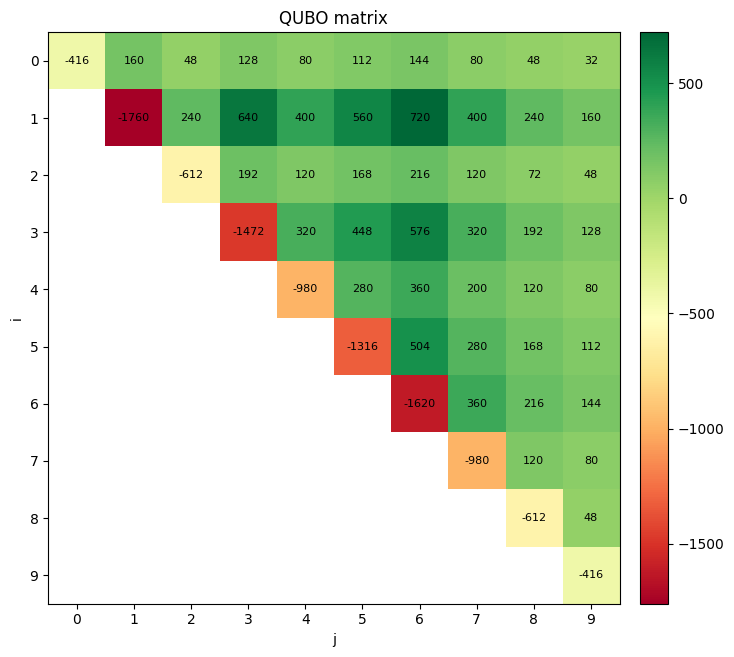

In [5]:
mask = np.tril(np.ones_like(Q), -1)  # lower triangle (excluding diagonal)
Q_masked = np.ma.array(Q, mask=mask)

fig, ax = plt.subplots(figsize=(8,8))

im = ax.imshow(Q_masked, cmap="RdYlGn")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.2)

fig.colorbar(im, cax=cax)

for i in range(n):
    for j in range(n):
        if j >= i:
            ax.text(j, i, f"{Q[i,j]:.0f}",
                    ha="center", va="center",
                    color="black", fontsize=8)

ax.set_title("QUBO matrix")
ax.set_xlabel("j")
ax.set_ylabel("i")
ax.set_xticks(range(n))
ax.set_yticks(range(n))

plt.show()

We can similarly visualize the QUBO matrix as a graph, where edge weights represent the cross terms, and node weights represent the single-variable terms.

In [6]:
import networkx as nx

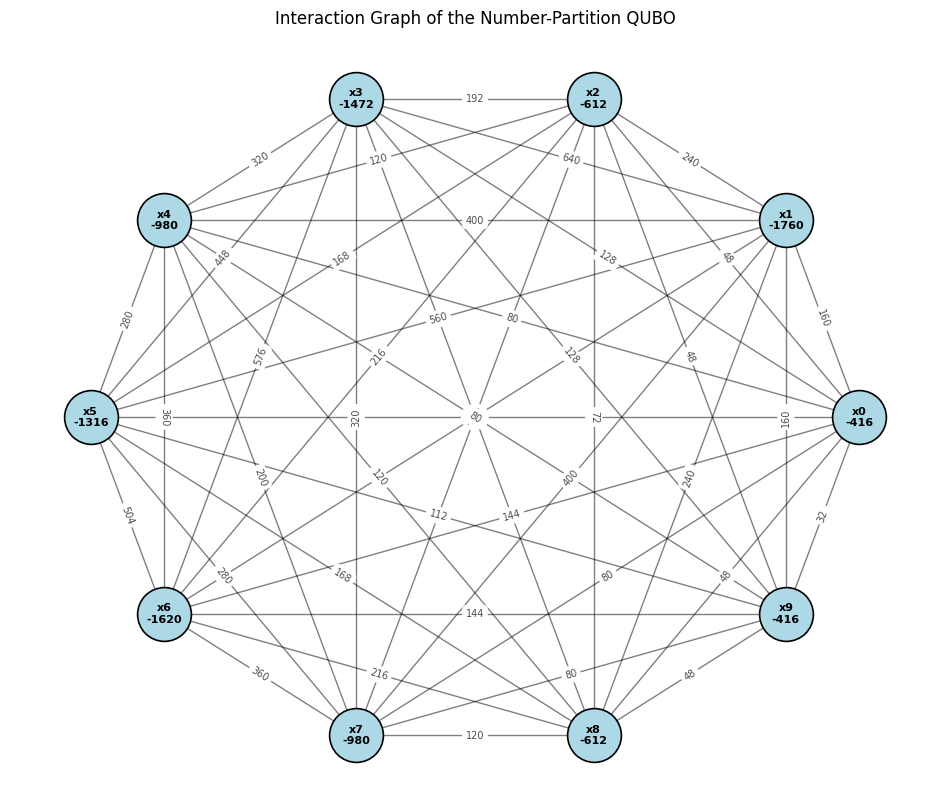

In [7]:
import networkx as nx

# Define the interactions from the off-diagonal elements of Q
edge_weights = {(i, j): Q[i, j] for i in range(n) for j in range(i + 1, n) if Q[i, j] != 0}

# Define the graph object G
G = nx.Graph()
G.add_nodes_from(range(n))
G.add_edges_from(edge_weights.keys())

# Define the layout position
pos = nx.circular_layout(G)

plt.figure(figsize=(12, 10))

# --- Draw nodes ---
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1500,
    node_color="lightblue",
    edgecolors="black",
    linewidths=1.2
)

# --- Node labels ---
nx.draw_networkx_labels(
    G,
    pos,
    labels={i: f"x{i}\n{int(Q[i,i])}" for i in range(n)},
    font_size=8,
    font_weight="bold"
)

# --- Edges  ---
nx.draw_networkx_edges(
    G,
    pos,
    width=1.0,
    alpha=0.5
)

# --- Edge labels ---
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={k: int(v) for k, v in edge_weights.items()},
    font_size=7,
    alpha=0.7
)

plt.title("Interaction Graph of the Number-Partition QUBO")
plt.axis("off")
plt.show()

We can solve QUBO problems using D-Wave's solvers via the `dimod` package. 

According to the [official documentation](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/#dimod):

> *dimod* is a shared API for samplers. It provides:
> - Classes for quadratic models—such as the binary quadratic model (BQM) class that contains Ising and QUBO models used by samplers such as the D-Wave quantum computer—and higher-order (non-quadratic) models.
> - Reference examples of samplers and composed samplers.
> - Abstract base classes for constructing new samplers and composed samplers.

The package allows the QUBO problem to be formulated in multiple ways, such as a matrix or a dictionary. The dictionary is the expected structure for modules such as [`BinaryQuadraticModel.from_qubo`](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/generated/dimod.binary.BinaryQuadraticModel.from_qubo.html), which expects:

> Coefficients of a quadratic unconstrained binary optimization (QUBO) problem as a dict of form {(u, v): bias, ...}, where u, v are binary-valued variables and bias is their associated coefficient.

A similar structure is used for [`sample_qubo`](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/generated/dimod.Sampler.sample_qubo.html).

Next, we encode the matrix $Q$ as a dictionary. We provide two equivalent methods: the first uses a compact nested comprehension, and the second uses a more explicit approach with two for-loops.

In [8]:
qubo = {(i,j): Q[i,j] for i in range(n) for j in range(i,n) if Q[i,j] != 0}

qubo2 = {}

for i in range(n):
    qubo2[(i, i)] = Q[i, i]
    for j in range(i+1, n):
        if Q[i, j] != 0:
            qubo2[(i, j)] = Q[i, j]

# Check if the two dictionaries are identical
print(f"Are the QUBO dictionaries identical? {qubo == qubo2}")

Are the QUBO dictionaries identical? True


While the dictionary contains the raw coefficients, we wrap it in a `BinaryQuadraticModel` (BQM) object. The BQM is the standard data structure used by D-Wave solvers; it provides a unified interface for manipulating the problem, such as converting between binary and spin variables. 

In [9]:
import dimod
from dimod import BinaryQuadraticModel

bqm = dimod.BinaryQuadraticModel.from_qubo(qubo)
bqm

BinaryQuadraticModel({0: -416.0, 1: -1760.0, 2: -612.0, 3: -1472.0, 4: -980.0, 5: -1316.0, 6: -1620.0, 7: -980.0, 8: -612.0, 9: -416.0}, {(1, 0): 160.0, (2, 0): 48.0, (2, 1): 240.0, (3, 0): 128.0, (3, 1): 640.0, (3, 2): 192.0, (4, 0): 80.0, (4, 1): 400.0, (4, 2): 120.0, (4, 3): 320.0, (5, 0): 112.0, (5, 1): 560.0, (5, 2): 168.0, (5, 3): 448.0, (5, 4): 280.0, (6, 0): 144.0, (6, 1): 720.0, (6, 2): 216.0, (6, 3): 576.0, (6, 4): 360.0, (6, 5): 504.0, (7, 0): 80.0, (7, 1): 400.0, (7, 2): 120.0, (7, 3): 320.0, (7, 4): 200.0, (7, 5): 280.0, (7, 6): 360.0, (8, 0): 48.0, (8, 1): 240.0, (8, 2): 72.0, (8, 3): 192.0, (8, 4): 120.0, (8, 5): 168.0, (8, 6): 216.0, (8, 7): 120.0, (9, 0): 32.0, (9, 1): 160.0, (9, 2): 48.0, (9, 3): 128.0, (9, 4): 80.0, (9, 5): 112.0, (9, 6): 144.0, (9, 7): 80.0, (9, 8): 48.0}, 0.0, 'BINARY')

The same result can be attained from the matrix representation Q with `BinaryQuadraticModel(Q, dimod.BINARY)` or equivalently `dimod.BinaryQuadraticModel(Q, "BINARY")`.

In [10]:
BinaryQuadraticModel(Q, dimod.BINARY) == dimod.BinaryQuadraticModel(Q, "BINARY") == bqm

True

We can use the `ExactSolver` method to solve the QUBO problem exactly, which is feasible for small problems. This sampler performs a brute-force search of all possible states. 

In [11]:
sampler = dimod.ExactSolver()

The `sampler.sample(bqm)` function executes the solver against our model. The resulting `sampleset` is a specialized object that stores the binary configurations, their corresponding energy levels, and metadata about the solver's performance.

In [12]:
sampleset = sampler.sample(bqm)

The `sampleset.lowest()` method returns a new `SampleSet` containing all samples that share the absolute minimum energy. 
This is particularly useful for symmetric problems like the number partitioning, where swapping all 0s for 1s (or vice versa) results in the same mathematical partition and the same energy.

In [13]:
sampleset.lowest()

SampleSet(rec.array([([1, 1, 1, 0, 1, 1, 0, 0, 0, 0], -2916., 1),
           ([1, 1, 0, 1, 0, 1, 0, 0, 0, 0], -2916., 1),
           ([0, 0, 1, 1, 0, 1, 1, 0, 0, 0], -2916., 1),
           ([0, 1, 1, 0, 1, 0, 1, 0, 0, 0], -2916., 1),
           ([1, 0, 1, 1, 1, 0, 1, 0, 0, 0], -2916., 1),
           ([0, 1, 0, 1, 0, 0, 1, 0, 0, 0], -2916., 1),
           ([0, 1, 1, 0, 0, 0, 1, 1, 0, 0], -2916., 1),
           ([1, 0, 1, 1, 0, 0, 1, 1, 0, 0], -2916., 1),
           ([0, 0, 0, 1, 1, 0, 1, 1, 0, 0], -2916., 1),
           ([1, 1, 1, 0, 0, 1, 0, 1, 0, 0], -2916., 1),
           ([1, 0, 0, 1, 1, 1, 0, 1, 0, 0], -2916., 1),
           ([0, 1, 0, 0, 1, 1, 0, 1, 0, 0], -2916., 1),
           ([1, 1, 0, 0, 0, 1, 0, 1, 1, 0], -2916., 1),
           ([0, 0, 1, 0, 0, 1, 1, 1, 1, 0], -2916., 1),
           ([1, 0, 1, 0, 1, 0, 1, 1, 1, 0], -2916., 1),
           ([1, 0, 0, 1, 0, 0, 1, 1, 1, 0], -2916., 1),
           ([0, 1, 0, 0, 0, 0, 1, 1, 1, 0], -2916., 1),
           ([1, 1, 1, 0, 0, 0, 1, 0, 1

In [14]:
len(sampleset.lowest())

46

We see that the sampler returns 46 solutions. This includes all solutions repeated due to the symmetry discussed earlier, which is exactly twice the 23 unique partitions found.

We can verify the physical meaning of our results by mapping the binary samples back to our original list of numbers $C$. By using `record.sample`, we access the raw NumPy array of bitstrings inside the `SampleSet` object. Below, we verify the partitions and sums for the first 5 optimal outputs. 

In [15]:
# Get the list of the first 5 optimal samples
top_5_samples = sampleset.lowest().record.sample[:5]

print(f"Original Numbers (C): {C}\n")
print("-" * 30)

for i, sample in enumerate(top_5_samples):
    # Map indices to groups based on the binary value (0 or 1)
    group_a = [C[idx] for idx in range(n) if sample[idx] == 0]
    group_b = [C[idx] for idx in range(n) if sample[idx] == 1]

    print(f"Solution {i+1}:")
    print(f"  Group A: {group_a} (Sum: {sum(group_a)})")
    print(f"  Group B: {group_b} (Sum: {sum(group_b)})")
    print("-" * 30)

Original Numbers (C): [2, 10, 3, 8, 5, 7, 9, 5, 3, 2]

------------------------------
Solution 1:
  Group A: [8, 9, 5, 3, 2] (Sum: 27)
  Group B: [2, 10, 3, 5, 7] (Sum: 27)
------------------------------
Solution 2:
  Group A: [3, 5, 9, 5, 3, 2] (Sum: 27)
  Group B: [2, 10, 8, 7] (Sum: 27)
------------------------------
Solution 3:
  Group A: [2, 10, 5, 5, 3, 2] (Sum: 27)
  Group B: [3, 8, 7, 9] (Sum: 27)
------------------------------
Solution 4:
  Group A: [2, 8, 7, 5, 3, 2] (Sum: 27)
  Group B: [10, 3, 5, 9] (Sum: 27)
------------------------------
Solution 5:
  Group A: [10, 7, 5, 3, 2] (Sum: 27)
  Group B: [2, 3, 8, 5, 9] (Sum: 27)
------------------------------


The `sampler.first` property returns the single configuration with the absolute lowest energy found. In this Number Partitioning problem, multiple different configurations share the same minimum energy. `.first` simply returns the one encountered first by the algorithm.

In [16]:
sampleset.first

Sample(sample={0: 1, 1: 1, 2: 1, 3: 0, 4: 0, 5: 0, 6: 1, 7: 0, 8: 1, 9: 0}, energy=-2916.0, num_occurrences=1)

By sorting the energies of all 1024 possible states from the `ExactSolver`, we can visualize the "Energy Landscape." The flat section at the bottom represents the 46 optimal solutions we identified earlier. Any state on the upward curve represents a "poor" partition where the difference between the two sums is larger. The steeper the curve, the worse the balance between Group A and Group B.

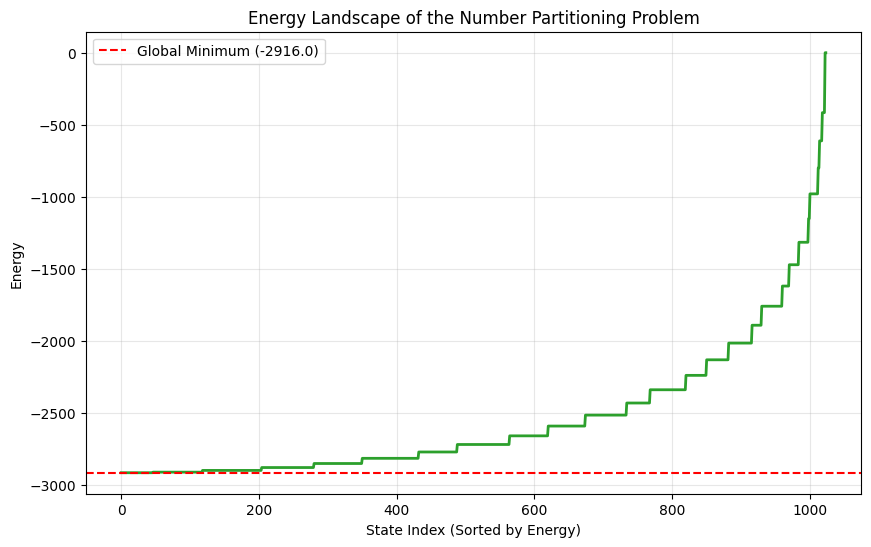

In [17]:
# Extract all energies and sort them from lowest to highest
all_energies = sorted(sampleset.record.energy)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(all_energies, color='#2ca02c', linewidth=2)

# Label the "Optimal Valley"
plt.axhline(y=min(all_energies), color='r', linestyle='--', label=f'Global Minimum ({min(all_energies)})')

plt.title("Energy Landscape of the Number Partitioning Problem")
plt.xlabel("State Index (Sorted by Energy)")
plt.ylabel("Energy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Now that we have completed solving the QUBO problem using D-Wave's exact solver, we can move to the simulated annealing sampler. This requires another package from the Ocean SDK called [`neal`](https://github.com/dwavesystems/dwave-neal), which is an implementation of a simulated annealing sampler. 

We initialize the sampler using the `SimulatedAnnealingSampler()` class. Unlike ExactSolver, which mathematically scans every possible state, simulated annealing is a probabilistic heuristic. While ExactSolver visits $2^n$ states once, simulated annealing performs a specific number of random "walks" to find the lowest energy. We specify `num_reads` to tell the solver how many of these independent attempts to make. Increasing `num_reads` improves the probability of finding the true global minimum among many possible local minima.

In [18]:
from neal import SimulatedAnnealingSampler

sampler_neal = SimulatedAnnealingSampler()
sampleset_neal = sampler_neal.sample(bqm, num_reads=10000)

print(sampleset_neal.first)

best_energy_neal = sampleset_neal.first.energy
optimal_neal = sampleset_neal.filter(lambda row: row.energy == best_energy_neal)

print(len(optimal_neal))

Sample(sample={0: 1, 1: 1, 2: 0, 3: 1, 4: 1, 5: 0, 6: 0, 7: 0, 8: 0, 9: 1}, energy=-2916.0, num_occurrences=1)
6041


We observe that approximately 60% of the 10,000 runs successfully converged to an optimal solution. This high success rate indicates that the energy landscape for this specific problem instance is relatively easy for the simulated annealing algorithm to navigate.

We can also verify all the solutions found by the simulated annealing sampler and map them back to their original numerical values to confirm the partitions.

In [19]:
# Create a new sampleset with only 5 rows
first_five_optimal = optimal_neal.truncate(5)

for row in first_five_optimal.data():
    x = row.sample
    P1 = [C[i] for i in range(len(C)) if x[i] == 0]
    P2 = [C[i] for i in range(len(C)) if x[i] == 1]
    print("sample =", x)
    print("P1 =", P1, "sum =", sum(P1))
    print("P2 =", P2, "sum =", sum(P2))
    print()

sample = {0: 0, 1: 0, 2: 0, 3: 1, 4: 0, 5: 1, 6: 1, 7: 0, 8: 1, 9: 0}
P1 = [2, 10, 3, 5, 5, 2] sum = 27
P2 = [8, 7, 9, 3] sum = 27

sample = {0: 0, 1: 1, 2: 1, 3: 0, 4: 0, 5: 0, 6: 1, 7: 1, 8: 0, 9: 0}
P1 = [2, 8, 5, 7, 3, 2] sum = 27
P2 = [10, 3, 9, 5] sum = 27

sample = {0: 1, 1: 1, 2: 1, 3: 0, 4: 0, 5: 0, 6: 1, 7: 0, 8: 1, 9: 0}
P1 = [8, 5, 7, 5, 2] sum = 27
P2 = [2, 10, 3, 9, 3] sum = 27

sample = {0: 0, 1: 1, 2: 0, 3: 0, 4: 0, 5: 0, 6: 1, 7: 1, 8: 1, 9: 0}
P1 = [2, 3, 8, 5, 7, 2] sum = 27
P2 = [10, 9, 5, 3] sum = 27

sample = {0: 0, 1: 0, 2: 1, 3: 0, 4: 1, 5: 0, 6: 1, 7: 1, 8: 1, 9: 1}
P1 = [2, 10, 8, 7] sum = 27
P2 = [3, 5, 9, 5, 3, 2] sum = 27



We have now explored several ways to solve a number partitioning problem using the QUBO framework. It began with a simple brute-force approach using tools such as `itertools.product` to verify the logic, followed by the use of D-Wave's `ExactSolver` for an exhaustive search, and finally the `neal` simulated annealing sampler for a heuristic-based solution.

While simulated annealing is a classical heuristic that runs on standard CPUs, it provides a functional baseline for the QUBO framework. For larger, more complex problem instances that become difficult for classical tools to handle, one could choose to submit the same QUBO model to D-Wave's quantum processing unit (QPU). This allows for the use of quantum annealing as an alternative solver for non-tractable optimization challenges.

While we have solved a demo number partitioning problem using a QUBO formulation, number partitioning also underlies many real‑world tasks that require balancing or splitting resources, such as workload distribution for shipments, partitioning of power or energy grids, and partitioning of communication networks. These logistics, power‑grid, and communication‑network examples are intended as use cases where balanced partitioning models like number partitioning could, in principle, be applied. 

--- 
### Minor Embedding: Mapping Logic to Hardware

To solve a QUBO on a physical D-Wave QPU, one typically performs minor embedding. While our mathematical model assumes all variables can interact, the physical qubits on the chip have limited connectivity. Minor embedding uses a heuristic to map these abstract logical variables onto specific physical qubits.

Because the hardware topologies are not fully connected, a single logical variable is often represented by a chain of multiple physical qubits. This process is called minor embedding because we are mathematically identifying our problem graph as a graph minor of the physical hardware layout.

As of March 2026, the main hardware topologies include Chimera, Pegasus, and Zephyr. These layouts feature different specifications and maximum connectivity degrees; choosing the appropriate topology is a key step in optimizing solver performance for a given problem. The D-Wave [`minorminer`](https://github.com/dwavesystems/minorminer) library is a common heuristic tool used for this process. 

For more detailed technical information, refer to the following D-Wave documentation:

* [Embedding Guidance](https://docs.dwavequantum.com/en/latest/quantum_research/embedding_guidance.html)
* [Hardware Topologies Overview](https://docs.dwavequantum.com/en/latest/quantum_research/topologies.html)
* [What is the Chimera Topology?](https://support.dwavesys.com/hc/en-us/articles/360003695354-What-Is-the-Chimera-Topology)
* [What is the Pegasus Topology?](https://support.dwavesys.com/hc/en-us/articles/360054564874-What-Is-the-Pegasus-Topology)
* [What is the Zephyr Topology?](https://support.dwavesys.com/hc/en-us/articles/6820989477911-What-Is-the-Zephyr-Topology)

---
### Performance Comparison: Quantum Annealing vs. Classical Approaches

QUBO problems are instances of NP-hard problems, and in general they are intractable problems for which efficient algorithms that provide deterministic solutions for the general case do not exist. As such, algorithms that attempt to solve them are heuristic. There are currently no theoretical guarantees that quantum annealing provides a speedup for solving QUBO problems compared to classical methods. Classical approaches include, but are not limited to, simulated annealing, tabu search, and genetic and evolutionary algorithms.

Whether quantum annealers offer a genuine computational advantage remains an open question. A 2017 preprint on [arXiv](https://arxiv.org/abs/1705.07452v1) by Tameem Albash and Daniel Lidar, titled "Evidence for a Limited Quantum Speedup on a Quantum Annealer", reported that "We establish the first example of a limited quantum speedup for an experimental quantum annealer", while "we do not find evidence for an unqualified quantum speedup: simulated quantum annealing exhibits the best scaling by a significant margin". By the time the work appeared in [Physical Review X](https://journals.aps.org/prx/abstract/10.1103/PhysRevX.8.031016) in 2018, the title had become "Demonstration of a Scaling Advantage for a Quantum Annealer over Simulated Annealing" with revised phrasing.

That said, the use of quantum annealing and the D-Wave platform for solving various optimization problems remains an active and ongoing area of research, suggesting the scientific community retains genuine interest in the prospects of quantum annealers. Research in highly specific physics tasks, the motivating factor behind exploring quantum annealing hardware to begin with, rooted in the Ising model, carries its own dedicated line of inquiry as well.

A work by researchers at D-Wave and collaborating institutions, titled *Beyond-classical computation in quantum simulation", published in [Science](https://www.science.org/doi/10.1126/science.ado6285), claims in its abstract:

> We show that several leading approximate methods based on tensor networks and neural networks cannot achieve the same accuracy as the quantum annealer within a reasonable time frame. Thus, quantum annealers can answer questions of practical importance that may remain out of reach for classical computation.

While such peer-reviewed results are certainly encouraging, it is still worthwhile to ask a few questions when evaluating claims of quantum advantage, especially as such claims are becoming more frequent:

1. **Problem formulation**: Has the problem been shaped to favour quantum hardware, or does it maintain a general framework open to diverse approaches?
2. **Scope**: Does the problem have broad industrial applications, or does it target a specialized audience such as a specific area of scientific research? In other words, what is the utilitarian scope: how many people stand to be impacted, and how wide is the breadth of applicability?
3. **Task nature**: Is the problem being solved practical and useful, or is it a toy problem?
4. **Classical baselines**: Given that several historical claims of quantum advantage were later met with competitive classical approaches, sometimes controversially, what classical and approximate methods have the authors tested their results against?


These questions are meant only as a guide for evaluating such claims; they are not intended to cast doubt on existing peer-reviewed results. In the end, we do not need to force a conclusion.Ultimately, time, reproducibility and longitudinal benchmarking will determine the validity of these claims.

---
### Conclusion 

In this tutorial, we introduced several foundational concepts, including QUBO problems, Ising models, adiabatic quantum computing, and quantum annealing. We discussed the principles of formulating a QUBO problem, how such formulations relate to Boolean and logical constraints, and how penalty functions can be used to transform constrained problems into unconstrained QUBO forms. We also explored optimization hierarchies and identified where QUBO problems fit within this broader landscape. Importantly, not all optimization problems are expected to benefit from quantum speedups, and identifying problem classes where quantum hardware provides an advantage remains an active area of research.

We then solved a toy example, the number partitioning problem, first via brute force and later using D-Wave’s Ocean SDK simulator tools. Through this process, we demonstrated how to encode a problem as a QUBO and how to submit jobs to a solver. In practical, large-scale settings, these jobs can be executed on D-Wave quantum hardware via cloud services. We also discussed practical challenges associated with hardware execution, particularly the need to map logical qubits to physical qubits on a device, which makes graph embedding techniques an essential component of the workflow.

Finally, we briefly addressed the ongoing question of whether quantum annealing can deliver meaningful speedups for QUBO problems or specialized domains such as physics. While the evidence is still emerging, there are promising indications in certain cases. We concluded by proposing a framework for critically evaluating claims of quantum advantage, focusing on problem scope and classical baselines. As hardware topologies evolve and embedding techniques improve, the effectiveness of quantum annealers will continue to be assessed against high-performing classical baselines. Ultimately, longitudinal benchmarking and the scaling of physical qubits will play a central role in determining the long-term industrial impact of quantum-assisted optimization.

---
### Appendix
---

### Appendix 1: Biography 

 - Ernst Ising (1900-1998) was a German physicist known for the development of the Ising model. He studied mathematics and physics at the University of Göttingen and the University of Hamburg. In 1924, he earned his Doctor of Philosophy from the University of Hamburg under the supervision of Wilhelm Lenz. His dissertation, titled *Contribution to the Theory of Ferromagnetism* (Beitrag zur Theorie des Ferromagnetismus), explored a linear chain of magnetic moments that could only take two positions, "up" or "down".

    As a Jewish scientist, Ising was barred from teaching and research after the rise of the Nazi regime in 1933. He eventually moved to the United States in 1947.  He spent the remainder of his career as a Professor of Physics at Bradley University in Peoria, Illinois, where he was recognized as an exceptional educator until his retirement in 1976. Although the Ising model became a cornerstone of statistical mechanics during his lifetime, Ising himself remained primarily dedicated to teaching rather than active scientific research in his later years.

 - Hidetoshi Nishimori, born in [1954](https://www.nec.com/en/press/201810/images/1001-01-01.pdf), is a Japanese theoretical physicist and a pioneer in the field of quantum computing. He obtained his undergraduate (BSc), master's (MSc), and PhD degrees from the University of Tokyo.  His research has primarily focused on the statistical mechanics of random spin systems and spin glasses. After completing his studies, he held postdoctoral positions at [Carnegie-Mellon University and Rutgers University](https://web.archive.org/web/20260328200914/https://ithems.riken.jp/en/members/hidetoshi-nishimori) before returning to Japan to join the Tokyo Institute of Technology.

    With Tadashi Kadowaki, he wrote the seminal 1998 paper "[Quantum annealing in the transverse Ising model](https://arxiv.org/abs/cond-mat/9804280)" that proposed quantum annealing as a way to solve combinatorial optimization problems using quantum fluctuations, which served as the theoretical foundation of D-Wave systems. He has received numerous prestigious awards, including the [fourth IBM Japan Science Prize (1990)](https://www.nec.com/en/press/201810/images/1001-01-01.pdf), [the Nishina Memorial Prize (2006)](https://www.nishina-mf.or.jp/project_en/kinen_en/), awarded to physicists for their outstanding achievements in the field of basic and applied physics, and [2018 NEC C&C Prize](https://www.candc.or.jp/en/2018/group_a.html) for his contributions to the fundamental mechanisms of quantum annealing machines. In recent times, he remains a leading figure in the global quantum community, serving as a Professor at the Institute of Innovative Research at the Institute of Science Tokyo (formerly Tokyo Tech) and a Senior Visiting Scientist at [RIKEN iTHEMS](https://ithems.riken.jp/en/members/hidetoshi-nishimori).

---
### Appendix 2: References and Suggested Readings

1. Glover, Fred; Kochenberger, Gary; and Du, Yu (2018). *A Tutorial on Formulating and Using QUBO Models*. Available at: https://wigner.hu/~koniorczykmatyas/qubo/literature/1811.11538.pdf [[arXiv]](https://arxiv.org/abs/1811.11538).

2. Kadowaki, Tadashi and Nishimori, Hidetoshi (1998). *Quantum Annealing in the Transverse Ising Model*. Physical Review E, 5355-5363. Available at: https://doi.org/10.1103/PhysRevE.58.5355 [[arXiv]](https://arxiv.org/abs/cond-mat/9804280).

3. Farhi, Edward; Goldstone, Jeffrey; and Gutmann, Sam (2000). *A Quantum Approximate Optimization Algorithm*. [[arXiv]](https://arxiv.org/abs/quant-ph/0001106).

4. D-Wave Systems. (n.d.). *What is Quantum Annealing?* D-Wave Documentation. Accessed March, 29, 2026. Available at: [https://docs.dwavequantum.com/en/latest/quantum_research/quantum_annealing_intro.html](https://docs.dwavequantum.com/en/latest/quantum_research/quantum_annealing_intro.html)

5. D-Wave Systems. (n.d.). Intro to Embedding. D-Wave Documentation. Accessed March, 29, 2026. Available at:[https://docs.dwavequantum.com/en/latest/quantum_research/embedding_intro.html](https://docs.dwavequantum.com/en/latest/quantum_research/embedding_intro.html)

6. D-Wave Systems. (n.d.). Embedding Guidance. D-Wave Documentation. Accessed March, 29, 2026. Available at: [https://docs.dwavequantum.com/en/latest/quantum_research/embedding_guidance.html](https://docs.dwavequantum.com/en/latest/quantum_research/embedding_guidance.html)

7. D-Wave Systems. (n.d.). Topologies. D-Wave Documentation. Accessed March, 29, 2026. Available at: [https://docs.dwavequantum.com/en/latest/quantum_research/topologies.html](https://docs.dwavequantum.com/en/latest/quantum_research/topologies.html)

8. D-Wave Systems. (n.d.). QUBOs and Ising Models. D-Wave Documentation. Accessed March, 29, 2026. Available at: [https://docs.dwavequantum.com/en/latest/quantum_research/qubo_ising.html](https://docs.dwavequantum.com/en/latest/quantum_research/qubo_ising.html)

9. Cai, Jun; Macready, William G.; and Roy, Aidan (2014). *A Practical Heuristic for Finding Graph Minors*. [[arXiv](https://arxiv.org/abs/1406.2741)].

10. Lobe, Elisabeth; and Lutz, Annette (2024). *Minor Embedding in Broken Chimera and Derived Graphs is NP-complete*. Theoretical Computer Science. Available at: https://doi.org/10.1016/j.tcs.2023.114369 [[arXiv](https://arxiv.org/abs/2110.08325) preprint (2021): titled "Minor Embedding in Broken Chimera and Pegasus Graphs is NP-complete"]

11. Pelofske, Elijah (2024). *4-Clique Network Minor Embedding for Quantum Annealers*. Physical Review Applied. Available at: https://doi.org/10.1103/PhysRevApplied.21.034023. [[arXiv](https://arxiv.org/abs/2301.08807)]

12. Gómez-Tejedor, Aitor; Osaba, Eneko; and Villar-Rodriguez, Esther (2026). *Addressing the Minor-Embedding Problem in Quantum Annealing and Evaluating State-of-the-Art Algorithm Performance*. Future Generation Computer Systems, 182. Available at: https://doi.org/10.1016/j.future.2026.108481 [[arXiv](https://arxiv.org/abs/2504.13376)]

13. Minatoy, Yuichiro (2019). *Looking at Pegasus Topology on D-Wave Machine*. Medium. Available at: https://minatoyuichiro.medium.com/looking-at-pegasus-topology-on-d-wave-machine-4d068c1b9afc

14. D-Wave Systems. (n.d.). Recruit Communications: Applying Quantum Computing to Digital Marketing. Customer Case Story. Accessed March, 29, 2026. Available at: [https://www.dwavequantum.com/media/i2fjhzy2/recruit_case_story_v5.pdf](https://www.dwavequantum.com/media/i2fjhzy2/recruit_case_story_v5.pdf)

15. D-Wave Systems. (2021). Ocean Programs for Beginners [Whitepaper]. Accessed March 29, 2026. Available at: https://www.dwavequantum.com/media/fmtj2fw3/20210920_ofbguide.pdf. 

16. Bernal Neira, David E. (2020). Quantum Integer Programming: Lecture 7 - Quantum Annealing [Lecture Slides]. Carnegie Mellon University / 47-779 Course - Fall 2020. Available at: https://bernalde.github.io/QuIP/slides/47-779%20Lecture%207%20-%20Quantum%20Annealing.pdf

17. Bernal Neira, David E. (2020). Quantum Integer Programming (QuIP): QUBO Notebook. Google Colab Notebook. Available at: https://colab.research.google.com/github/bernalde/QuIP/blob/master/notebooks/Notebook%205%20-%20QUBO.ipynb

18. Montanez, Alejandro (2024). *Quadratic Unconstrained Binary Optimization*. PennyLane Demos. Published February 28, 2024; last updated October 14, 2025. Accessed March 29, 2026. Available at: https://pennylane.ai/qml/demos/tutorial_QUBO.

19. Boulanger, Pierre (2023). *Introduction to D-Wave Ocean SDK. GitHub Gist*. Available at: https://gist.github.com/pierre-boulanger/9a2c0543d839933ae8eba19f186d7aff

20. Jij Inc. (n.d.). OpenJij Tutorial. GitHub Repository. Available at: https://github.com/Jij-Inc/OpenJijTutorial

21. D-Wave Systems. (n.d.). Ocean Packages. D-Wave Ocean Software Documentation. Accessed March 29, 2026. Available at: [https://docs.dwavequantum.com/en/latest/ocean/packages.html](https://docs.dwavequantum.com/en/latest/ocean/packages.html)

22. D-Wave Systems. (n.d). D-Wave Examples Repository. GitHub. Accessed March 29, 2026. Available at: [https://github.com/dwave-examples](https://github.com/dwave-examples)

23. Iosue, Joseph T. (n.d.). qubovert: The One-Stop Package for Formulating, Simulating, and Solving Problems in Boolean and Spin Form [Software documentation]. Available at: https://qubovert.readthedocs.io/en/latest/. [[GitHub](https://github.com/jtiosue/qubovert)]

24. NEOS Guide (n.d.). *Types of Optimization Problems*. Accessed March 29, 2026. Available at: https://neos-guide.org/guide/types/

25. D-Wave Systems. (2020). Pegasus Embeddings [Video]. D-Wave YouTube Channel. YouTube. Available at: https://www.youtube.com/watch?v=aAhvyxzJyQE